## Visualization of the prediction accuracy of the models on the test sets

In [1]:
import pathlib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
eval_file = pathlib.Path("../data/processed/test_sets/evaluation_results_w_dist.tsv")
eval_df = pd.read_csv(eval_file, sep="\t")
eval_df["rep"] = eval_df.rep.fillna(-1).astype(int)
eval_df["test_count_0"] = eval_df.test_count_0.fillna(-1).astype(int)
eval_df["test_count_1"] = eval_df.test_count_1.fillna(-1).astype(int)
eval_df["phylo_dist_min"] = eval_df.phylo_dist_min.fillna(0)
eval_df.drop(columns=["phylo_dist_mind"], inplace=True)
eval_df

,train_dataset,test_dataset,phenotype,rep,acc,bacc,mcc,f1,precision,recall,test_count_0,test_count_1,phylo_dist_avg,phylo_dist_min,jacc_dist_avg,jacc_dist_min
0,atleaf,in_abb,Alanine,0,0.758621,0.757143,0.516752,0.740741,0.769231,0.714286,15,14,1.537431,0.073062,0.798109,0.164483
1,atleaf,in_abb,Alanine,1,0.758621,0.720588,0.507770,0.631579,0.857143,0.500000,17,12,1.599447,0.112859,0.811740,0.222953
2,atleaf,in_abb,Alanine,2,0.689655,0.686275,0.368949,0.727273,0.750000,0.705882,12,17,1.526927,0.097591,0.804536,0.238627
3,atleaf,in_abb,Alanine,3,0.724138,0.723810,0.447619,0.733333,0.733333,0.733333,14,15,1.498976,0.074916,0.798979,0.162794
4,atleaf,in_abb,Alanine,4,0.827586,0.823810,0.666955,0.800000,0.909091,0.714286,15,14,1.588008,0.068658,0.804453,0.136440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Mannose,-1,0.919188,0.867321,0.769443,0.948257,0.929795,0.968452,-1,-1,0.000000,0.000000,0.000000,0.000000
1564,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Serine,-1,0.842427,0.841014,0.683746,0.853945,0.847256,0.861515,-1,-1,0.000000,0.000000,0.000000,0.000000
1565,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Sucrose,-1,0.807758,0.794873,0.597533,0.844717,0.839959,0.853255,-1,-1,0.000000,0.000000,0.000000,0.000000
1566,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Trehalose,-1,0.856770,0.839600,0.704515,0.885787,0.861146,0.917647,-1,-1,0.000000,0.000000,0.000000,0.000000


## Baseline performance (CV)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True

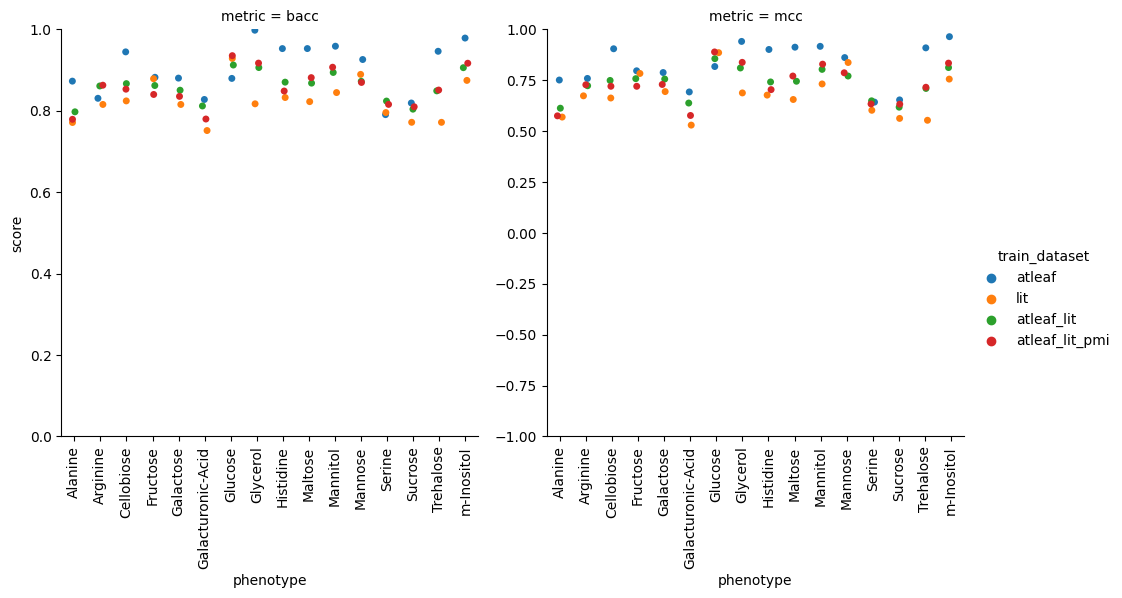

In [3]:
plot_data = eval_df[eval_df.test_dataset.str.endswith("_cv") & eval_df.train_dataset.isin(["atleaf", "lit", "atleaf_lit", "atleaf_lit_pmi"])]
plot_data = plot_data.melt(id_vars=["train_dataset", "phenotype"], value_vars=["bacc", "mcc"], var_name="metric", value_name="score")
g = sns.catplot(data=plot_data, x="phenotype", y="score",  hue="train_dataset", col="metric", col_wrap=2, sharey=False)
for i, ax in enumerate(g.axes.flat):
    if i == 1:
        ax.set_ylim(-1, 1)
    else:
        ax.set_ylim(0, 1)
    for label in ax.get_xticklabels():
        label.set_rotation(90)

## Test dataset performance

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


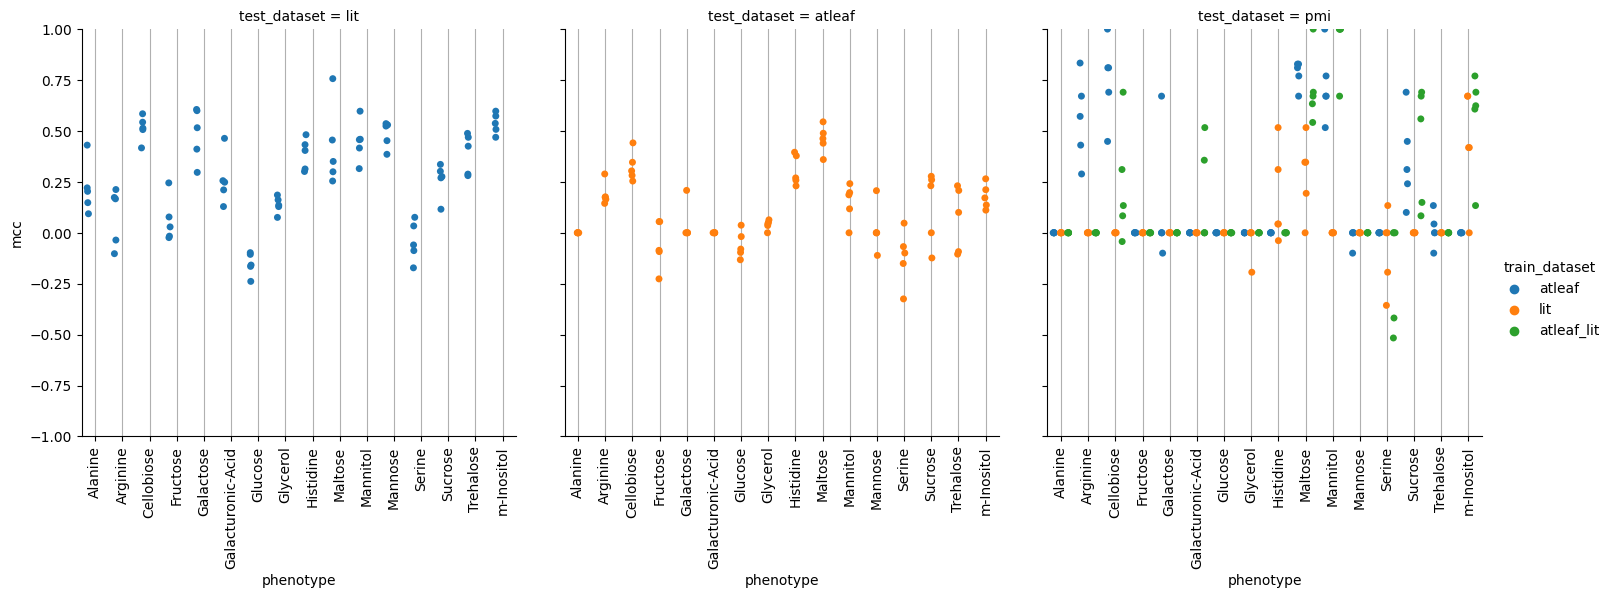

In [4]:
plot_data = eval_df[~eval_df.test_dataset.str.endswith("_cv")]
plot_data = plot_data[plot_data.test_dataset.isin(["lit", "pmi", "atleaf"]) & plot_data.train_dataset.isin(["atleaf", "lit", "atleaf_lit"])]
g = sns.catplot(data=plot_data, x="phenotype", y="mcc", hue="train_dataset", col="test_dataset", kind="strip", col_wrap=3, col_order=["lit", "atleaf", "pmi"], dodge=True)
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

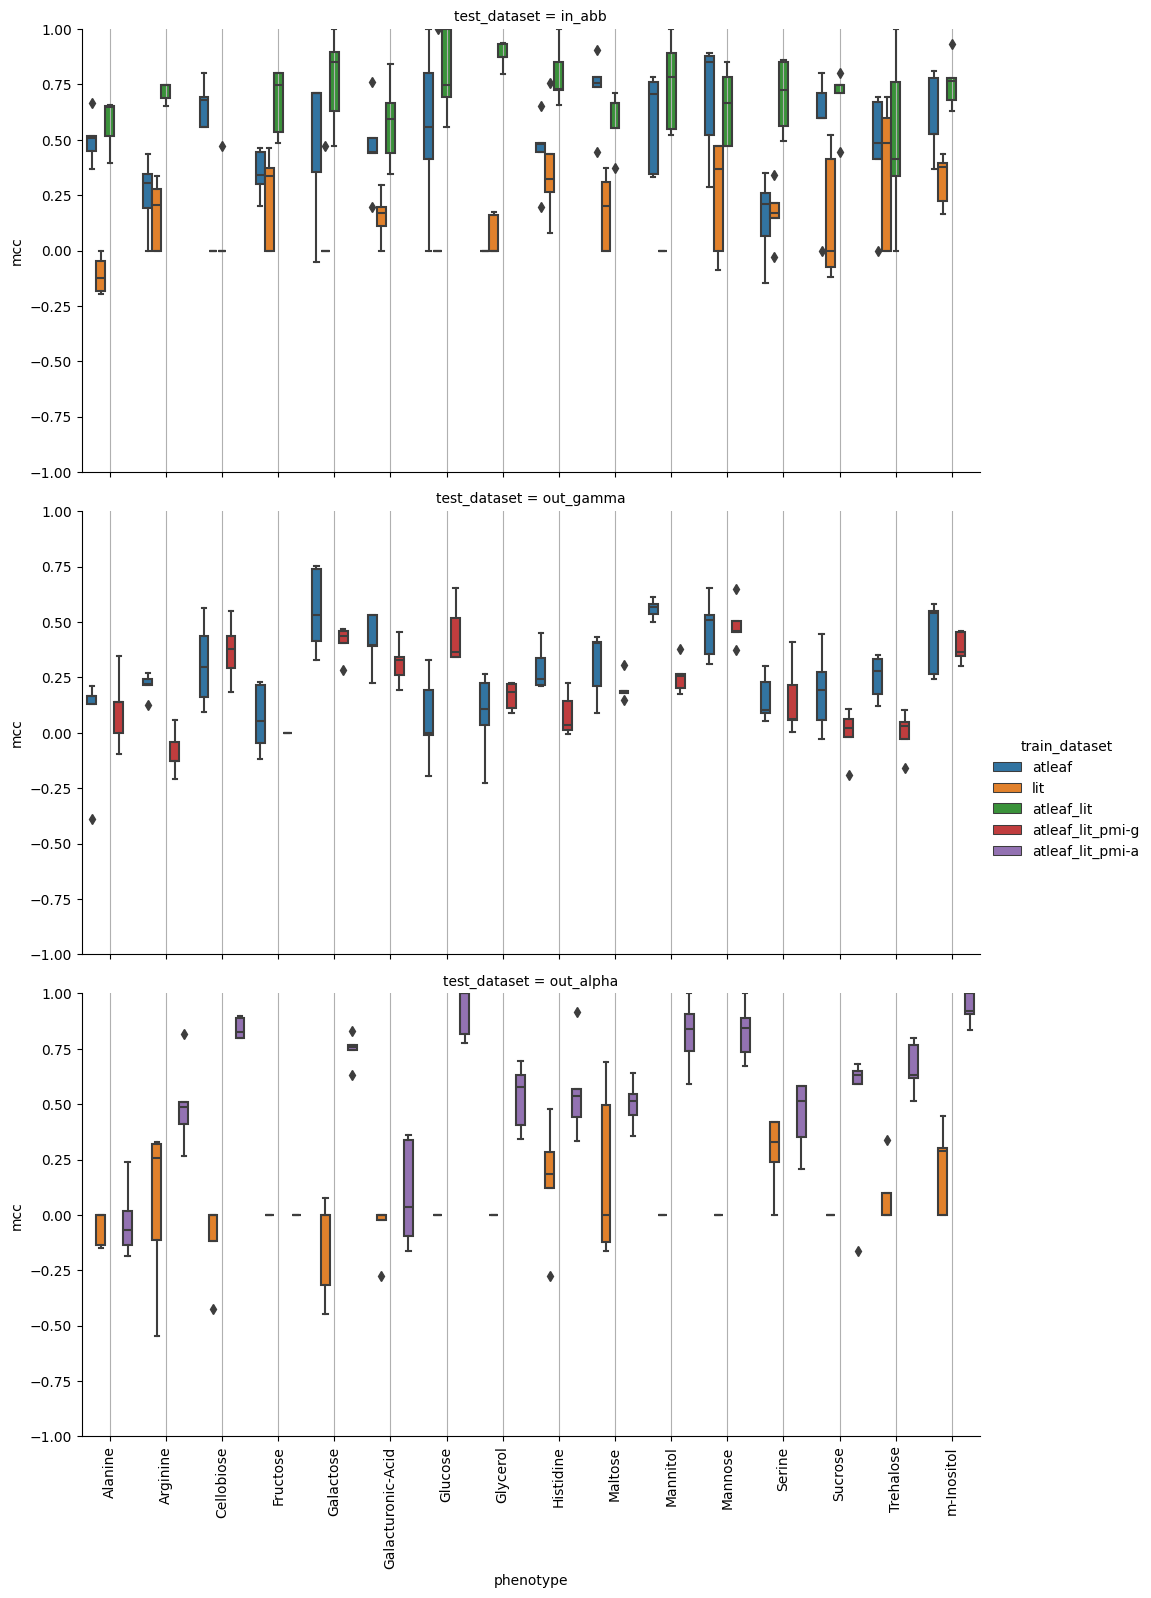

In [5]:
plot_data = eval_df[~eval_df.test_dataset.str.endswith("_cv")]
plot_data = plot_data[plot_data.test_dataset.isin(["in_abb", "out_gamma", "out_alpha"]) & plot_data.train_dataset.isin(["atleaf", "lit", "atleaf_lit", "atleaf_lit_pmi-g", "atleaf_lit_pmi-a"])]
g = sns.catplot(data=plot_data, x="phenotype", y="mcc", hue="train_dataset", col="test_dataset", kind="box", col_wrap=1, aspect=2)
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

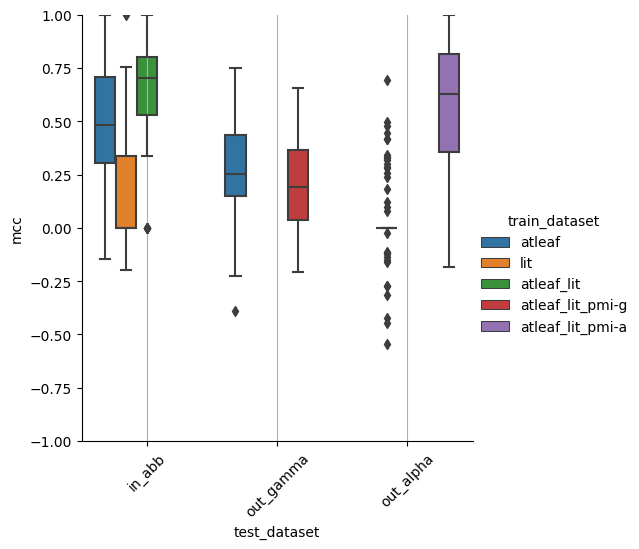

In [6]:
plot_data = eval_df[~eval_df.test_dataset.str.endswith("_cv")]
plot_data = plot_data[plot_data.test_dataset.isin(["in_abb", "out_gamma", "out_alpha"]) & plot_data.train_dataset.isin(["atleaf", "lit", "atleaf_lit", "atleaf_lit_pmi-g", "atleaf_lit_pmi-a"])]
g = sns.catplot(data=plot_data, x="test_dataset", y="mcc", hue="train_dataset", kind="box")
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(45)

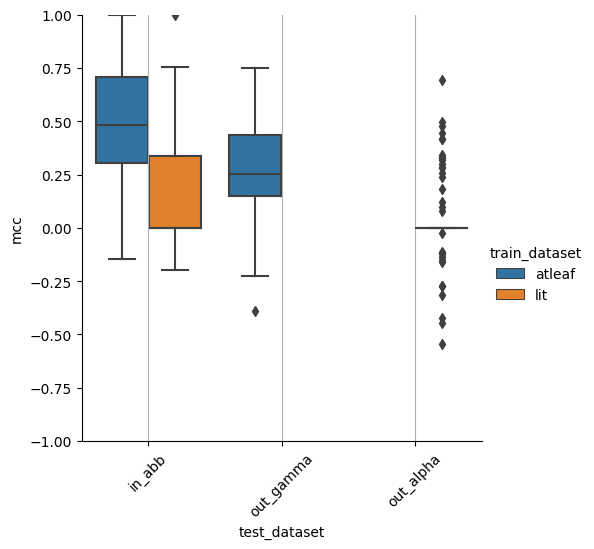

In [18]:
plot_data = eval_df[~eval_df.test_dataset.str.endswith("_cv")]
plot_data = plot_data[plot_data.test_dataset.isin(["in_abb", "out_gamma", "out_alpha"]) & plot_data.train_dataset.isin(["atleaf", "lit"])]
g = sns.catplot(data=plot_data, x="test_dataset", y="mcc", hue="train_dataset", kind="box")
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(45)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


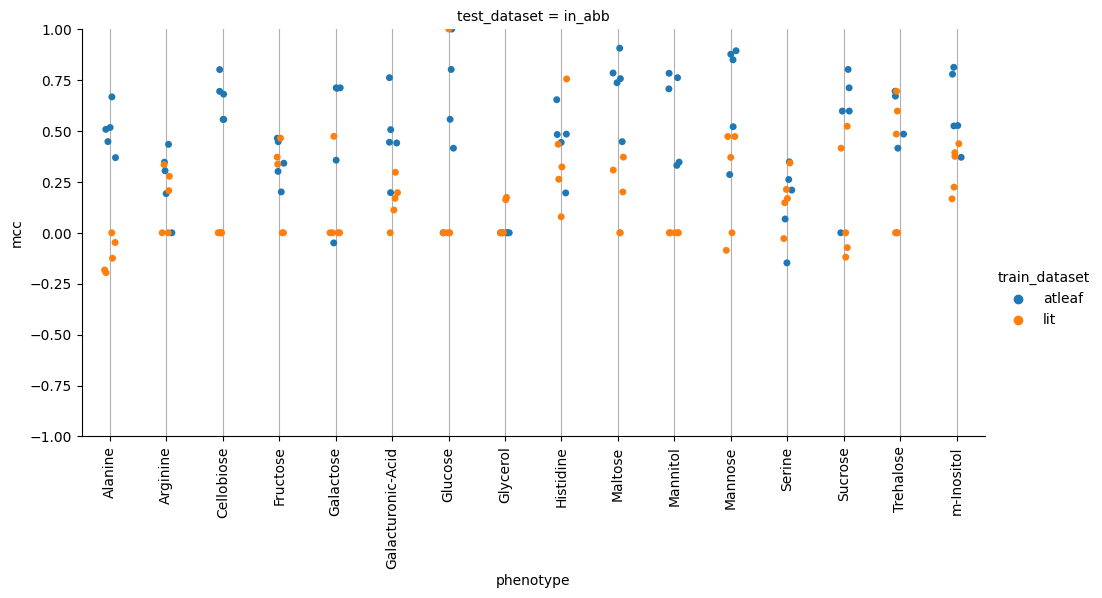

In [16]:
plot_data = eval_df[~eval_df.test_dataset.str.endswith("_cv")]
plot_data = plot_data[plot_data.test_dataset.isin(["in_abb"]) & plot_data.train_dataset.isin(["atleaf", "lit"])]
g = sns.catplot(data=plot_data, x="phenotype", y="mcc", hue="train_dataset", col="test_dataset", kind="strip", col_wrap=1, aspect=2)
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


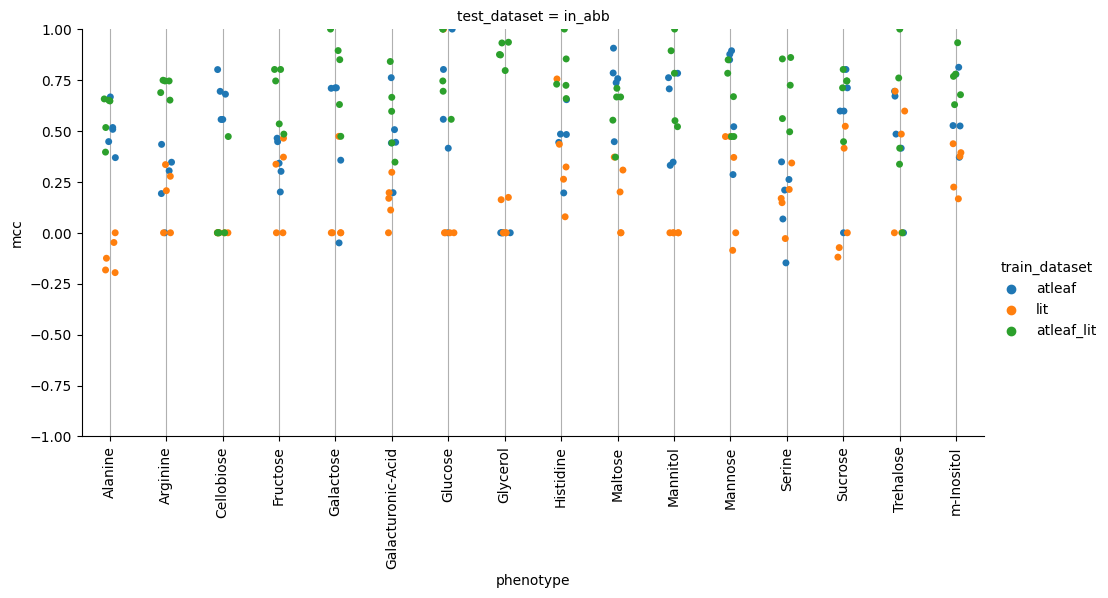

In [17]:
plot_data = eval_df[~eval_df.test_dataset.str.endswith("_cv")]
plot_data = plot_data[plot_data.test_dataset.isin(["in_abb"]) & plot_data.train_dataset.isin(["atleaf", "lit", "atleaf_lit"])]
g = sns.catplot(data=plot_data, x="phenotype", y="mcc", hue="train_dataset", col="test_dataset", kind="strip", col_wrap=1, aspect=2)
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

## Correlation between distance and scores

In [7]:
eval_df

,train_dataset,test_dataset,phenotype,rep,acc,bacc,mcc,f1,precision,recall,test_count_0,test_count_1,phylo_dist_avg,phylo_dist_min,jacc_dist_avg,jacc_dist_min
0,atleaf,in_abb,Alanine,0,0.758621,0.757143,0.516752,0.740741,0.769231,0.714286,15,14,1.537431,0.073062,0.798109,0.164483
1,atleaf,in_abb,Alanine,1,0.758621,0.720588,0.507770,0.631579,0.857143,0.500000,17,12,1.599447,0.112859,0.811740,0.222953
2,atleaf,in_abb,Alanine,2,0.689655,0.686275,0.368949,0.727273,0.750000,0.705882,12,17,1.526927,0.097591,0.804536,0.238627
3,atleaf,in_abb,Alanine,3,0.724138,0.723810,0.447619,0.733333,0.733333,0.733333,14,15,1.498976,0.074916,0.798979,0.162794
4,atleaf,in_abb,Alanine,4,0.827586,0.823810,0.666955,0.800000,0.909091,0.714286,15,14,1.588008,0.068658,0.804453,0.136440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Mannose,-1,0.919188,0.867321,0.769443,0.948257,0.929795,0.968452,-1,-1,0.000000,0.000000,0.000000,0.000000
1564,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Serine,-1,0.842427,0.841014,0.683746,0.853945,0.847256,0.861515,-1,-1,0.000000,0.000000,0.000000,0.000000
1565,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Sucrose,-1,0.807758,0.794873,0.597533,0.844717,0.839959,0.853255,-1,-1,0.000000,0.000000,0.000000,0.000000
1566,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Trehalose,-1,0.856770,0.839600,0.704515,0.885787,0.861146,0.917647,-1,-1,0.000000,0.000000,0.000000,0.000000


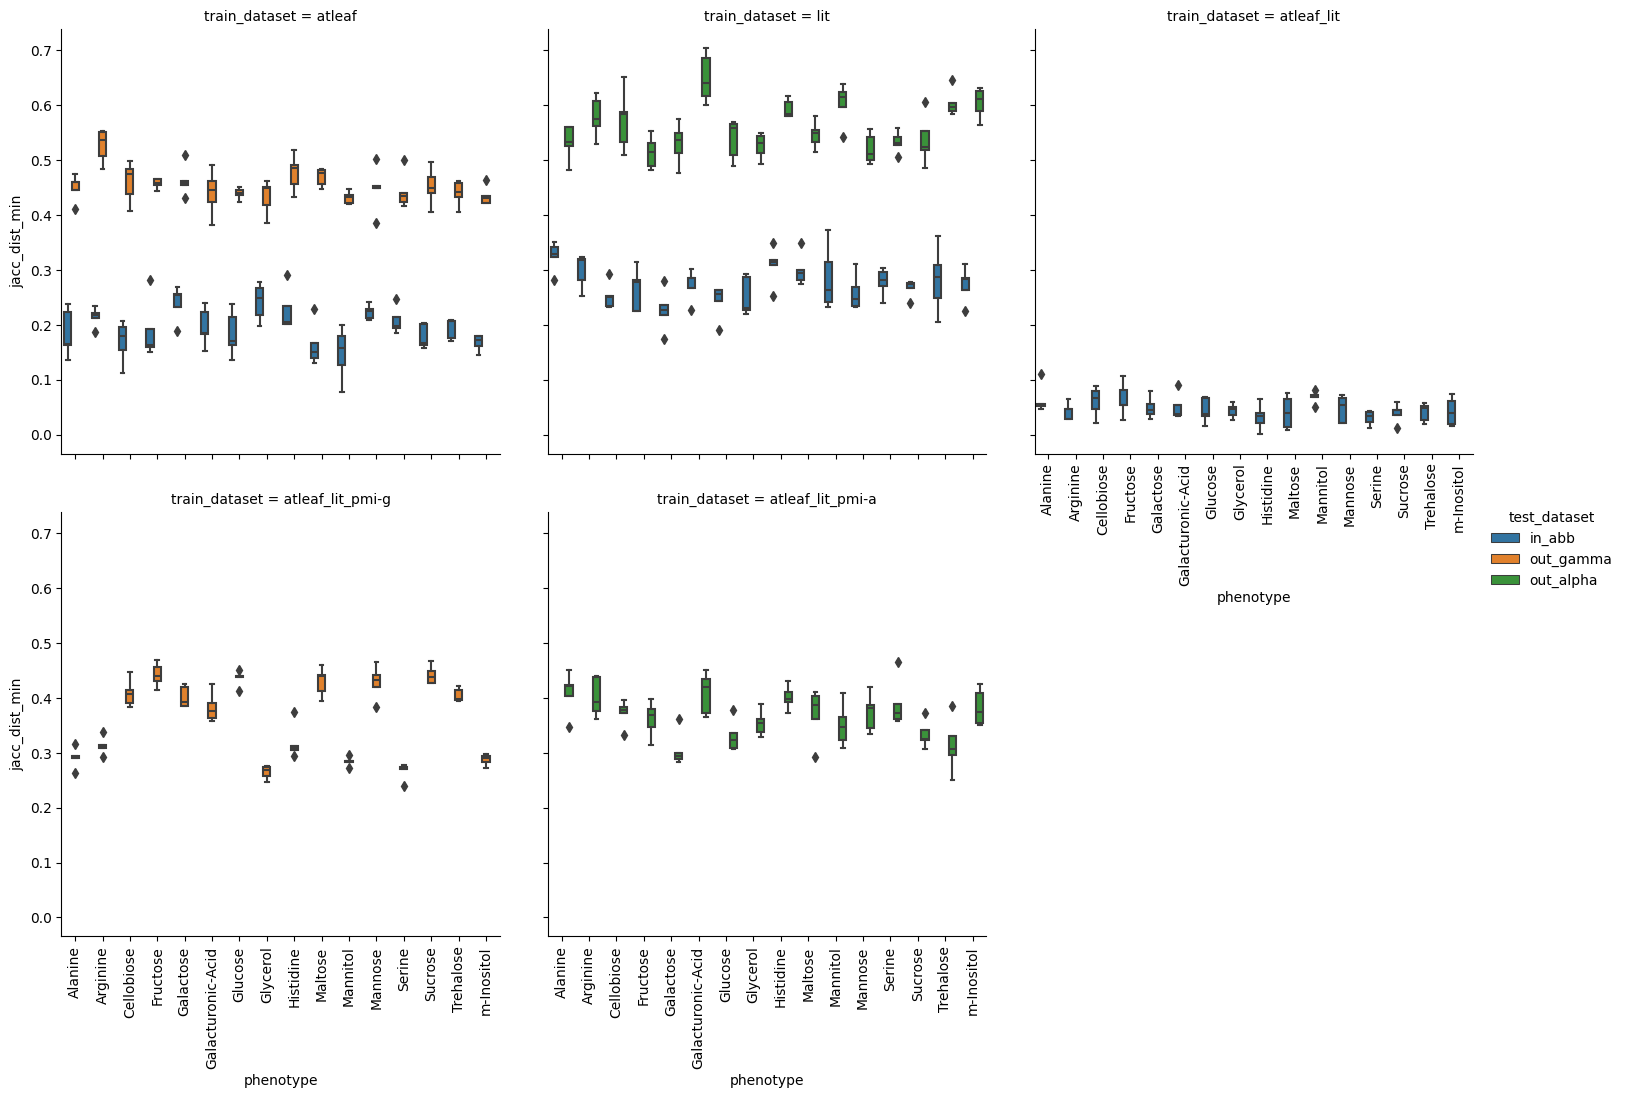

In [8]:
dist_metric = "jacc_dist_min"
# plot_data = eval_df.groupby(["train_dataset", "test_dataset", "phenotype"])[["mcc", dist_metric]].mean().reset_index().sort_values(by=["train_dataset", "test_dataset", "mcc"], ascending=False)
plot_data = eval_df[~eval_df.test_dataset.str.endswith("_cv")]
plot_data = plot_data[plot_data.test_dataset.isin(["in_abb", "out_gamma", "out_alpha"]) & plot_data.train_dataset.isin(["atleaf", "lit", "atleaf_lit", "atleaf_lit_pmi-g", "atleaf_lit_pmi-a"])]
g = sns.catplot(data=plot_data, x="phenotype", y=dist_metric, hue="test_dataset", col="train_dataset", kind="box", col_wrap=3)
for i, ax in enumerate(g.axes.flat):
    # ax.set_ylim(-1, 1)
    # ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

In [9]:
# apply groupby on phenotype column of eval_df and for each group calculate correlation between mcc and jacc_dist_min
corr_data = eval_df.groupby("phenotype").apply(lambda x: x[["mcc", "jacc_dist_min"]].corr().iloc[0, 1])
corr_data

/tmp/ipykernel_2587816/3188104858.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_data = eval_df.groupby("phenotype").apply(lambda x: x[["mcc", "jacc_dist_min"]].corr().iloc[0, 1])


phenotype
Alanine             -0.729538
Arginine            -0.398864
Cellobiose          -0.341570
Fructose            -0.843437
Galactose           -0.683172
Galacturonic-Acid   -0.783254
Glucose             -0.726645
Glycerol            -0.682683
Histidine           -0.667085
Maltose             -0.395350
Mannitol            -0.153706
Mannose             -0.713441
Serine              -0.646636
Sucrose             -0.566054
Trehalose           -0.616802
m-Inositol          -0.271173
dtype: float64

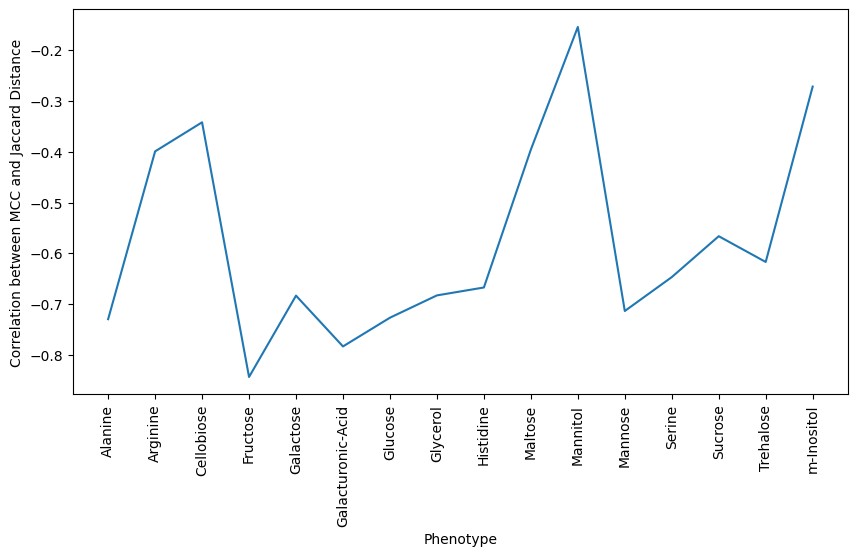

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(corr_data)
plt.xlabel("Phenotype")
plt.ylabel("Correlation between MCC and Jaccard Distance")
plt.xticks(rotation=90);

## BacDive test analysis

In [11]:
test_bacdive = pd.read_csv("../data/external/bacdive/pheno_predict_output.tsv", sep="\t")
test_bacdive.rename(columns={"phenotype_of_interest": "bacdive_phenotype", "trained_model_source": "train_dataset", "model_phenotype": "phenotype"}, inplace=True)
test_bacdive["category"] = test_bacdive.bacdive_phenotype.str.split("--").str[-1]
test_bacdive

,train_dataset,bacdive_phenotype,phenotype,accuracy,balanced_accuracy,precision,recall,f1_score,mcc,tn,tp,fn,fp,category
0,atleaf_lit_pmi-g,histidine--carbon_source,Histidine,0.738372,0.866864,1.000000,0.733728,0.846416,0.214145,3,124,45,0,carbon_source
1,atleaf_lit_pmi-a,alanine--carbon_source,Alanine,0.675949,0.834197,1.000000,0.668394,0.801242,0.209545,9,258,128,0,carbon_source
2,atleaf_lit,histidine--carbon_source,Histidine,0.581395,0.786982,1.000000,0.573964,0.729323,0.151521,3,97,72,0,carbon_source
3,atleaf,D-mannitol--assimilation,Mannitol,0.752111,0.770365,0.619784,0.838912,0.712889,0.521216,579,401,77,246,assimilation
4,atleaf,D-galactose--assimilation,Galactose,0.768707,0.757856,0.752688,0.864198,0.804598,0.532089,43,70,11,23,assimilation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,atleaf_lit-a,alpha-D-glucose--carbon_source,Glucose,0.650000,0.428105,0.826087,0.745098,0.783505,-0.121393,2,76,26,16,carbon_source
516,atleaf_lit-g,glucose--fermentation,Glucose,0.363043,0.427930,0.231511,0.571429,0.329519,-0.137363,95,72,54,239,fermentation
517,atleaf_lit-g,glycerol--builds_acid_from,Glycerol,0.336105,0.426711,0.187184,0.590426,0.284251,-0.133754,172,111,77,482,builds_acid_from
518,atleaf_lit-a,D-glucose--fermentation,Glucose,0.286582,0.372620,0.257818,0.623529,0.364798,-0.296179,148,371,224,1068,fermentation


In [12]:
import matplotlib.pyplot as plt
import  seaborn as sns

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


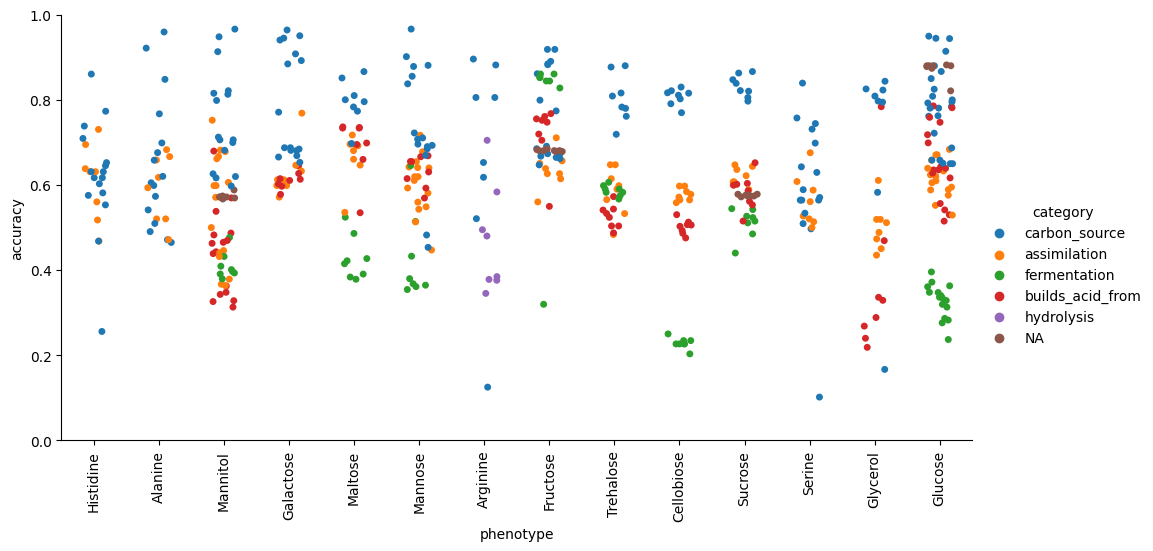

In [13]:
sns.catplot(data=test_bacdive, x="phenotype", y="accuracy", hue="category", kind="strip", aspect=2, jitter=0.2)
plt.xticks(rotation=90);
plt.ylim(0, 1);

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


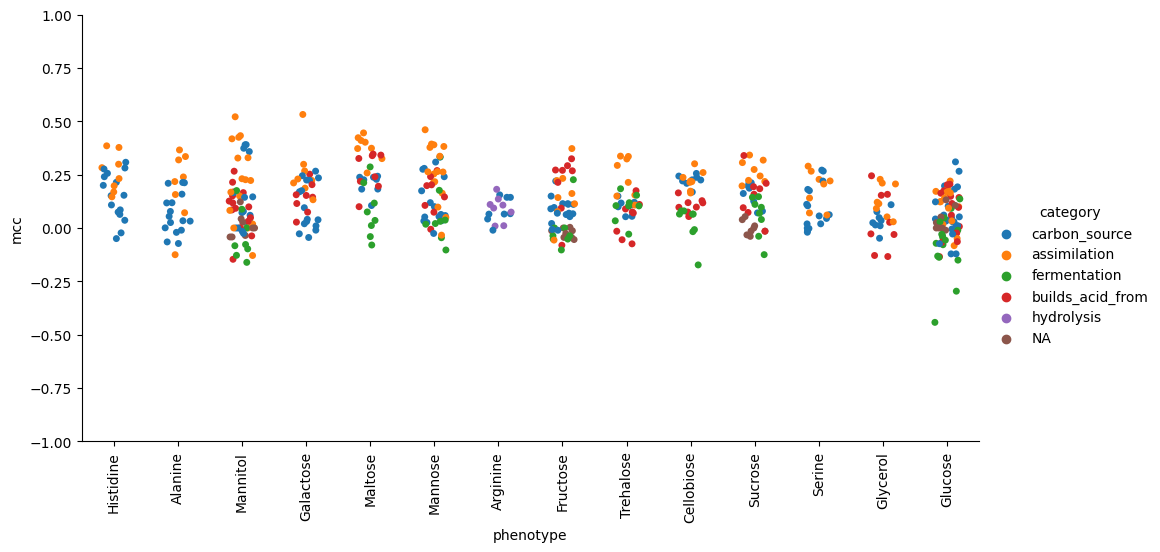

In [14]:
sns.catplot(data=test_bacdive, x="phenotype", y="mcc", hue="category", kind="strip", aspect=2, jitter=0.2)
plt.xticks(rotation=90);
plt.ylim(-1, 1);